In [2]:
import pandas as pd
import numpy as np

## Timestamp object

Time stamps reference particular moments in time (eg. Oct 24th 2022 at 7:00pm)

### Creating  Timestamp objects

In [6]:
# creaing a timestamp

pd.Timestamp('2026')


pandas._libs.tslibs.timestamps.Timestamp

In [9]:
type(pd.Timestamp('2026'))

pandas._libs.tslibs.timestamps.Timestamp

In [11]:
pd.Timestamp('2026/4/2')

Timestamp('2026-04-02 00:00:00')

In [12]:
# variations

In [13]:
pd.Timestamp('2026-4-2')

Timestamp('2026-04-02 00:00:00')

In [15]:
pd.Timestamp('2026, 4, 2')

Timestamp('2026-04-02 00:00:00')

In [26]:
# only year

pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [27]:
# using Text

pd.Timestamp('2nd April 2026')

Timestamp('2026-04-02 00:00:00')

In [36]:
# providing time also

pd.Timestamp('2026-04-02 09:29:00')

Timestamp('2026-04-02 09:29:00')

In [55]:
pd.Timestamp('2nd April 2026 9:30:00 AM')

Timestamp('2026-04-02 09:30:00')

In [56]:
# using datetime.datetime object

import datetime as dt

dt.datetime(2026,4,2,9,32)

datetime.datetime(2026, 4, 2, 9, 32)

In [57]:
x = pd.Timestamp(dt.datetime(2026,4,2,9,32))
x

Timestamp('2026-04-02 09:32:00')

In [58]:
# fetching attributes

print(x.year)
print(x.month)
print(x.day)
print(x.hour)
print(x.minute)
print(x.second)

2026
4
2
9
32
0


In [60]:
# why seprate objects to handle data and time when python already has datetime functionality ?

# syntax wise datetime is very convwnient
# But the performance takes a hit while working with huge data. List vs Numpy Array
# The warknesses of Python's datetime format inspired the Numpy team to add a set of native time series data type to NumPy
# The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly

In [64]:
import numpy as np
date = np.array('2026-04-02', dtype= np.datetime64)
date

array('2026-04-02', dtype='datetime64[D]')

In [65]:
print(date)

2026-04-02


In [66]:
date + np.arange(12)

array(['2026-04-02', '2026-04-03', '2026-04-04', '2026-04-05',
       '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
       '2026-04-10', '2026-04-11', '2026-04-12', '2026-04-13'],
      dtype='datetime64[D]')

- Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large 

- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

### DatetimeIndex Object

A collection of pandas timestamp

In [70]:
# from strings

pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2021/1/1'])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [72]:
type(pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2021/1/1'])[0])

pandas._libs.tslibs.timestamps.Timestamp

In [73]:
type(pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2021/1/1']))

pandas.core.indexes.datetimes.DatetimeIndex

In [74]:
# using python datetime object

pd.DatetimeIndex([dt.datetime(2023,1,1), dt.datetime(2023,1,1), dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2023-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [77]:
# using pd.timestamps

dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1), pd.Timestamp(2023,1,1), pd.Timestamp(2021,1,1)])
dt_index

DatetimeIndex(['2023-01-01', '2023-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [78]:
# using datetimeindex sa series index

pd.Series([1,2,3], index=dt_index)

2023-01-01    1
2023-01-01    2
2021-01-01    3
dtype: int64

### date_range function

In [83]:
# generate daily dates in a given range

pd.date_range(start='2026/1/5', end='2026/1/31')
# default para --> freq='D'

DatetimeIndex(['2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10', '2026-01-11', '2026-01-12',
               '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24',
               '2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28',
               '2026-01-29', '2026-01-30', '2026-01-31'],
              dtype='datetime64[ns]', freq='D')

In [86]:
# alternate days in a giive range
pd.date_range(start='2026/1/5', end='2026/1/31', freq='2D')    # skips one date, alternate dates

DatetimeIndex(['2026-01-05', '2026-01-07', '2026-01-09', '2026-01-11',
               '2026-01-13', '2026-01-15', '2026-01-17', '2026-01-19',
               '2026-01-21', '2026-01-23', '2026-01-25', '2026-01-27',
               '2026-01-29', '2026-01-31'],
              dtype='datetime64[ns]', freq='2D')

In [87]:
# Business days --> B

pd.date_range(start='2026/1/5', end='2026/1/31', freq='B')  

DatetimeIndex(['2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-12', '2026-01-13', '2026-01-14',
               '2026-01-15', '2026-01-16', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26',
               '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30'],
              dtype='datetime64[ns]', freq='B')

In [88]:
# W --> one week per day

pd.date_range(start='2026/1/5', end='2026/1/31', freq='W')  

DatetimeIndex(['2026-01-11', '2026-01-18', '2026-01-25'], dtype='datetime64[ns]', freq='W-SUN')

In [89]:
pd.date_range(start='2026/1/5', end='2026/1/31', freq='W-THU')  

DatetimeIndex(['2026-01-08', '2026-01-15', '2026-01-22', '2026-01-29'], dtype='datetime64[ns]', freq='W-THU')

In [92]:
# h --> Hourly date(factor)

pd.date_range(start='2026/1/5', end='2026/1/31', freq='h')

DatetimeIndex(['2026-01-05 00:00:00', '2026-01-05 01:00:00',
               '2026-01-05 02:00:00', '2026-01-05 03:00:00',
               '2026-01-05 04:00:00', '2026-01-05 05:00:00',
               '2026-01-05 06:00:00', '2026-01-05 07:00:00',
               '2026-01-05 08:00:00', '2026-01-05 09:00:00',
               ...
               '2026-01-30 15:00:00', '2026-01-30 16:00:00',
               '2026-01-30 17:00:00', '2026-01-30 18:00:00',
               '2026-01-30 19:00:00', '2026-01-30 20:00:00',
               '2026-01-30 21:00:00', '2026-01-30 22:00:00',
               '2026-01-30 23:00:00', '2026-01-31 00:00:00'],
              dtype='datetime64[ns]', length=625, freq='h')

In [93]:
pd.date_range(start='2026/1/5', end='2026/1/31', freq='6h')    # every 6 hours

DatetimeIndex(['2026-01-05 00:00:00', '2026-01-05 06:00:00',
               '2026-01-05 12:00:00', '2026-01-05 18:00:00',
               '2026-01-06 00:00:00', '2026-01-06 06:00:00',
               '2026-01-06 12:00:00', '2026-01-06 18:00:00',
               '2026-01-07 00:00:00', '2026-01-07 06:00:00',
               ...
               '2026-01-28 18:00:00', '2026-01-29 00:00:00',
               '2026-01-29 06:00:00', '2026-01-29 12:00:00',
               '2026-01-29 18:00:00', '2026-01-30 00:00:00',
               '2026-01-30 06:00:00', '2026-01-30 12:00:00',
               '2026-01-30 18:00:00', '2026-01-31 00:00:00'],
              dtype='datetime64[ns]', length=105, freq='6h')

In [103]:
# ME --> Month end

pd.date_range(start='2026/1/1', end='2026/3/31', freq='ME') 

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31'], dtype='datetime64[ns]', freq='ME')

In [102]:
# MS --> Month start

pd.date_range(start='2026/1/1', end='2026/3/31', freq='MS') 

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01'], dtype='datetime64[ns]', freq='MS')

In [107]:
# YE --> year end

pd.date_range(start='2026/1/5', end='2030/1/31', freq='YE') 

DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31'], dtype='datetime64[ns]', freq='YE-DEC')

In [110]:
# using periods (numeber of results)

pd.date_range(start='2026/1/1', periods=25, freq='D') 

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10', '2026-01-11', '2026-01-12',
               '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24',
               '2026-01-25'],
              dtype='datetime64[ns]', freq='D')

In [111]:
pd.date_range(start='2026/1/1', periods=25, freq='h') 

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 01:00:00',
               '2026-01-01 02:00:00', '2026-01-01 03:00:00',
               '2026-01-01 04:00:00', '2026-01-01 05:00:00',
               '2026-01-01 06:00:00', '2026-01-01 07:00:00',
               '2026-01-01 08:00:00', '2026-01-01 09:00:00',
               '2026-01-01 10:00:00', '2026-01-01 11:00:00',
               '2026-01-01 12:00:00', '2026-01-01 13:00:00',
               '2026-01-01 14:00:00', '2026-01-01 15:00:00',
               '2026-01-01 16:00:00', '2026-01-01 17:00:00',
               '2026-01-01 18:00:00', '2026-01-01 19:00:00',
               '2026-01-01 20:00:00', '2026-01-01 21:00:00',
               '2026-01-01 22:00:00', '2026-01-01 23:00:00',
               '2026-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='h')

### to_datetime function

convert an existing objects to pandas timestamp/datetimeindex objects

In [115]:
# simple series example

s = pd.Series(['2023/1/1', '2022/1/1', '2021/1/1'])
s

0    2023/1/1
1    2022/1/1
2    2021/1/1
dtype: object

In [117]:
s.str.split('/').str.get(0)

0    2023
1    2022
2    2021
dtype: object

In [118]:
pd.to_datetime(s)

0   2023-01-01
1   2022-01-01
2   2021-01-01
dtype: datetime64[ns]

In [119]:
pd.to_datetime(s).dt.year

0    2023
1    2022
2    2021
dtype: int32

In [120]:
pd.to_datetime(s).dt.month

0    1
1    1
2    1
dtype: int32

In [121]:
pd.to_datetime(s).dt.day

0    1
1    1
2    1
dtype: int32

In [123]:
pd.to_datetime(s).dt.month_name()

0    January
1    January
2    January
dtype: object

In [124]:
pd.to_datetime(s).dt.day_name()

0      Sunday
1    Saturday
2      Friday
dtype: object

In [125]:
# with errors

s = pd.Series(['2023/1/1', '2022/1/1', '2021/1332/1'])
s

0       2023/1/1
1       2022/1/1
2    2021/1332/1
dtype: object

In [127]:
# pd.to_datetime(s)    #--> ValueError: time data "2021/1332/1" doesn't match format "%Y/%m/%d", at position 2. You might want to try:

In [129]:
pd.to_datetime(s, errors='coerce')

0   2023-01-01
1   2022-01-01
2          NaT
dtype: datetime64[ns]

In [132]:
pd.to_datetime(s, errors='coerce').dt.year

0    2023.0
1    2022.0
2       NaN
dtype: float64

In [133]:
pd.to_datetime(s, errors='coerce').dt.month_name()

0    January
1    January
2        NaN
dtype: object

In [135]:
df = pd.read_csv('datasets/expense_data.csv')
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,11/22/2021 14:16,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,11/22/2021 14:16,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,11/21/2021 17:07,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,11/21/2021 15:50,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [136]:
df.shape

(277, 11)

In [137]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [140]:
df['Date'] = pd.to_datetime(df['Date'])

In [141]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


### dt accessor

Accessor object for datetime like properties of the Series values.

In [143]:
df['Date']

0     2022-03-02 10:11:00
1     2022-03-02 10:11:00
2     2022-03-01 19:50:00
3     2022-03-01 18:56:00
4     2022-03-01 18:22:00
              ...        
272   2021-11-22 14:16:00
273   2021-11-22 14:16:00
274   2021-11-21 17:07:00
275   2021-11-21 15:50:00
276   2021-11-21 13:30:00
Name: Date, Length: 277, dtype: datetime64[ns]

In [144]:
df['Date'].dt.year

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
272    2021
273    2021
274    2021
275    2021
276    2021
Name: Date, Length: 277, dtype: int32

In [145]:
df['Date'].dt.month_name()

0         March
1         March
2         March
3         March
4         March
         ...   
272    November
273    November
274    November
275    November
276    November
Name: Date, Length: 277, dtype: object

In [151]:
df['Date'].dt.is_month_end

0      False
1      False
2      False
3      False
4      False
       ...  
272    False
273    False
274    False
275    False
276    False
Name: Date, Length: 277, dtype: bool

In [150]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00


In [147]:
df['Date'].dt.is_quarter_end

0      False
1      False
2      False
3      False
4      False
       ...  
272    False
273    False
274    False
275    False
276    False
Name: Date, Length: 277, dtype: bool

In [148]:
df[df['Date'].dt.is_quarter_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1


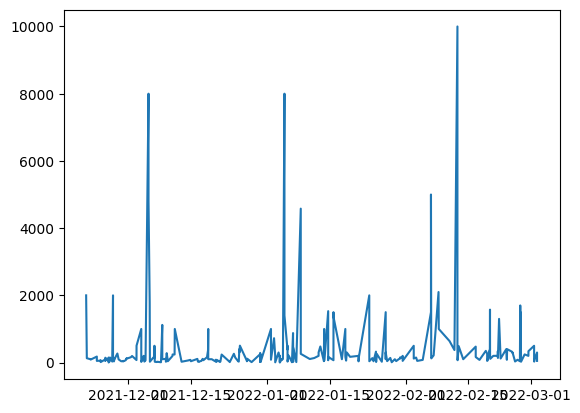

In [154]:
# plot graph

import matplotlib.pyplot as plt

plt.plot(df['Date'], df['INR'])

In [155]:
# day name wise bar chart/month wise bar chart

In [160]:
df['day_name'] = df['Date'].dt.day_name()

In [161]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


In [167]:
df.groupby('day_name')['INR'].sum()

day_name
Friday        6910.00
Monday        6248.95
Saturday     34421.02
Sunday       31542.40
Thursday      9570.51
Tuesday      17344.65
Wednesday     7740.47
Name: INR, dtype: float64

<Axes: xlabel='day_name'>

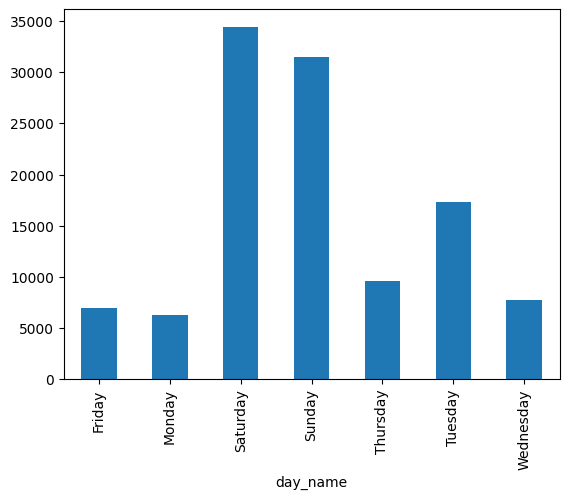

In [169]:
df.groupby('day_name')['INR'].sum().plot(kind='bar')

In [174]:
df['month_name'] = df['Date'].dt.month_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday,March


<Axes: xlabel='month_name'>

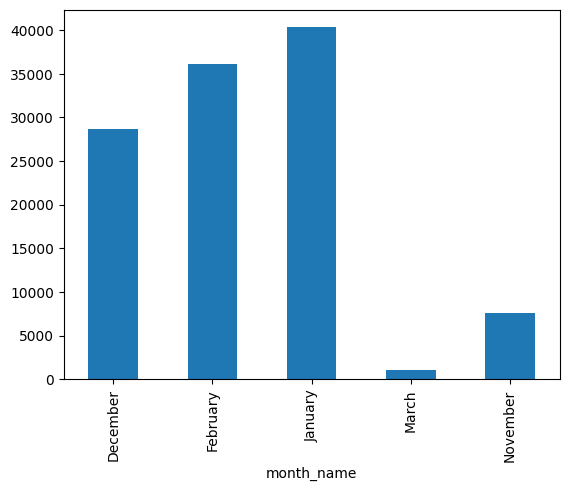

In [175]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')

<Axes: xlabel='month_name'>

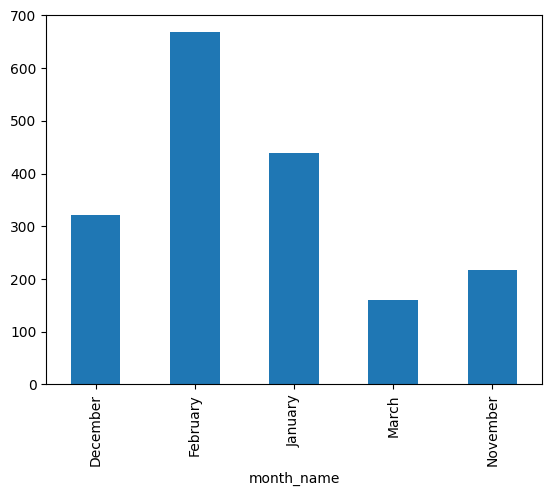

In [176]:
df.groupby('month_name')['INR'].mean().plot(kind='bar')

<Axes: xlabel='day_name'>

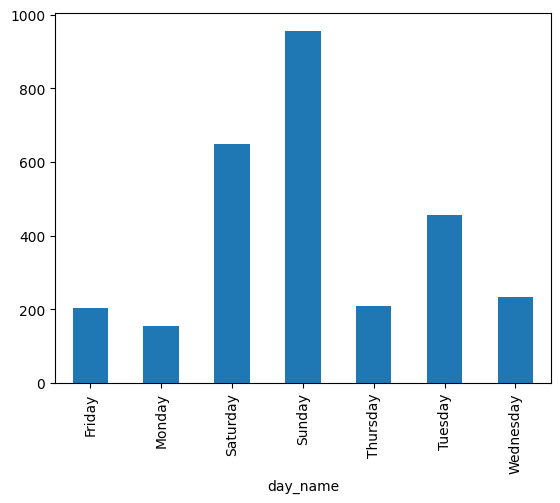

In [179]:
df.groupby('day_name')['INR'].mean().plot(kind='bar')

In [185]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,Monday,February
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,Monday,February
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,Monday,January
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,Monday,January
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,Monday,January
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,Tuesday,November
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,Tuesday,November
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,Tuesday,November


In [186]:
df[df['Date'].dt.is_month_end]['Amount']

7      339.15
8      200.00
61      50.00
62     200.00
63     153.00
242    115.00
243    128.00
244     70.00
Name: Amount, dtype: float64

In [187]:
df[df['Date'].dt.is_month_end]['Amount'].sum()

np.float64(1255.15)

In [190]:
df[df['Date'].dt.is_month_end].groupby('month_name')['Amount'].sum()

month_name
February    539.15
January     403.00
November    313.00
Name: Amount, dtype: float64